# Multipole Moment Comparison for Ion Trap Geometries -- BEM Solver

Replicates **Table 3.2** -- multipole ratios $p_N/p_2$ for eight trap cross-sections.

**Method -- Boundary Element Method (BEM):**
1. Discretize each electrode surface into boundary elements (line segments).
2. Build the Coulomb influence matrix using the 2-D Green's function (log kernel):
$$\phi(\mathbf{r}_N) = -\frac{1}{2\pi}\sum_{n \neq N} q_n \ln|\mathbf{r}_N - \mathbf{r}_n|$$
   This is the 2-D adaptation of the 3-D Coulomb relation $\phi_N = \frac{1}{4\pi\varepsilon_0}\sum_{n\neq N}\frac{q_n}{|\mathbf{r}_N-\mathbf{r}_n|}$.
3. Solve for the charge on each boundary element.
4. Evaluate the potential on a regular grid.
5. Fit the RF potential $\phi_{\mathrm{rf}}$ to a circular multipole expansion.
6. Compute the pseudopotential $\phi_{\mathrm{ps}} = \frac{q}{4m\Omega_{\mathrm{rf}}^2}(V_{\mathrm{rf}}\nabla\phi_{\mathrm{rf}})^2$.
7. Fit $\phi_{\mathrm{ps}}$ to a circular multipole expansion.
8. Report $p_N/p_2$ ratios for both.

**Physics validation** checks Laplace residual, electrode voltage accuracy, and far-field decay.

In [10]:
# ============================================================
# Cell 1 -- Imports & physical constants
# ============================================================
import numpy as np
from numpy.linalg import solve as dense_solve
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import minimize
import time, warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

ION_MASS   = 9.0121831 * 1.66054e-27   # kg (9Be+)
Q_E        = 1.602176634e-19            # C
V_RF_AMP   = 500.0                      # V  (peak RF amplitude)
OMEGA_RF   = 2.0 * np.pi * 30e6        # rad/s  (RF drive)

print('Setup complete.')
print(f'  Ion  : 9Be+, m = {ION_MASS:.4e} kg')
print(f'  RF   : V_rf = {V_RF_AMP} V, Omega/(2pi) = {OMEGA_RF/2/np.pi/1e6:.1f} MHz')

Setup complete.
  Ion  : 9Be+, m = 1.4965e-26 kg
  RF   : V_rf = 500.0 V, Omega/(2pi) = 30.0 MHz


In [11]:
# ============================================================
# Cell 2 -- BEM solver functions
# ============================================================

def electrode_mask(cx, cy, w, h, X, Y):
    """Boolean mask for a rectangle centred at (cx, cy)."""
    return (X >= cx - w/2) & (X <= cx + w/2) & (Y >= cy - h/2) & (Y <= cy + h/2)


def discretize_electrodes(electrodes, n_per_side=50):
    """
    Walk the 4 edges of each rectangular electrode and return boundary
    element data.

    Returns
    -------
    positions  : (N_elem, 2)  -- element centroid coordinates (x, y)
    lengths    : (N_elem,)    -- arc-length of each element
    potentials : (N_elem,)    -- prescribed voltage on each element
    elem_elec  : (N_elem,)    -- index of the parent electrode
    """
    all_pos, all_len, all_phi, all_idx = [], [], [], []

    for ei, e in enumerate(electrodes):
        cx, cy, w, h, V = e['cx'], e['cy'], e['w'], e['h'], e['V']
        x0, x1 = cx - w / 2, cx + w / 2
        y0, y1 = cy - h / 2, cy + h / 2

        corners = [(x0, y0), (x1, y0), (x1, y1), (x0, y1)]

        for k in range(4):
            ax, ay = corners[k]
            bx, by = corners[(k + 1) % 4]
            side_len = np.hypot(bx - ax, by - ay)
            n = max(2, int(round(n_per_side * side_len / max(w, h))))

            for j in range(n):
                t = (j + 0.5) / n
                mx = ax + t * (bx - ax)
                my = ay + t * (by - ay)
                all_pos.append((mx, my))
                all_len.append(side_len / n)
                all_phi.append(V)
                all_idx.append(ei)

    return (np.array(all_pos), np.array(all_len),
            np.array(all_phi), np.array(all_idx))


def build_influence_matrix(positions, lengths):
    """
    Construct the N x N influence matrix for 2-D BEM (log kernel).

    Off-diagonal: A[i,j] = -(lengths[j] / (2*pi)) * ln|r_i - r_j|
    Diagonal:     A[i,i] = (lengths[i] / (2*pi)) * (1 - ln(lengths[i] / 2))
    """
    N = len(positions)
    dx = positions[:, np.newaxis, 0] - positions[np.newaxis, :, 0]
    dy = positions[:, np.newaxis, 1] - positions[np.newaxis, :, 1]
    dist = np.sqrt(dx**2 + dy**2)
    np.fill_diagonal(dist, 1.0)   # placeholder to avoid log(0)

    A = -(lengths[np.newaxis, :] / (2.0 * np.pi)) * np.log(dist)

    diag = (lengths / (2.0 * np.pi)) * (1.0 - np.log(lengths / 2.0))
    np.fill_diagonal(A, diag)
    return A


def evaluate_bem_potential(positions, lengths, charges, eval_pts):
    """
    Sum Coulomb contributions from all boundary elements at eval_pts.

    Parameters
    ----------
    positions : (N_elem, 2)
    lengths   : (N_elem,)
    charges   : (N_elem,)   -- charge density * element length = total charge per element
    eval_pts  : (M, 2)

    Returns
    -------
    phi : (M,)
    """
    M = eval_pts.shape[0]
    N = positions.shape[0]

    CHUNK = 50000
    phi = np.zeros(M)
    q = charges  # q_n = sigma_n * dl_n already folded in by the solve

    for start in range(0, M, CHUNK):
        end = min(start + CHUNK, M)
        dx = eval_pts[start:end, 0, np.newaxis] - positions[np.newaxis, :, 0]
        dy = eval_pts[start:end, 1, np.newaxis] - positions[np.newaxis, :, 1]
        dist = np.sqrt(dx**2 + dy**2)
        dist = np.maximum(dist, 1e-30)
        phi[start:end] = np.dot(-np.log(dist) / (2.0 * np.pi), q)
    return phi


def solve_bem(electrodes, X, Y, n_per_side=50):
    """
    Full BEM solve for a set of rectangular electrodes on the grid (X, Y).

    Returns
    -------
    V        : (ny, nx)  potential on the grid
    electrodes : list (with 'mask' key added)
    fixed    : (ny, nx)  boolean mask of electrode pixels
    bem_data : dict with charges, positions, lengths, potentials for validation
    """
    ny, nx = X.shape

    fixed = np.zeros((ny, nx), dtype=bool)
    v_map = np.zeros((ny, nx))
    for e in electrodes:
        m = electrode_mask(e['cx'], e['cy'], e['w'], e['h'], X, Y)
        e['mask'] = m
        fixed[m] = True
        v_map[m] = e['V']

    positions, lengths, potentials, elem_elec = discretize_electrodes(
        electrodes, n_per_side=n_per_side)

    A = build_influence_matrix(positions, lengths)
    charges = dense_solve(A, potentials)

    grid_pts = np.column_stack([X.ravel(), Y.ravel()])
    V_flat = evaluate_bem_potential(positions, lengths, charges, grid_pts)
    V = V_flat.reshape(ny, nx)

    V[fixed] = v_map[fixed]

    bem_data = {
        'positions': positions,
        'lengths': lengths,
        'charges': charges,
        'potentials': potentials,
        'elem_elec': elem_elec,
    }
    return V, electrodes, fixed, bem_data


print('BEM solver functions loaded.')

BEM solver functions loaded.


In [12]:
# ============================================================
# Cell 3 -- Analysis functions (carried over from original)
# ============================================================

def find_rf_null(V, X, Y, guess_y=0.0):
    """
    Locate the RF null = saddle point of phi_rf where |grad phi_rf| is
    minimised.  For symmetric traps (guess_y==0) the null is at the origin;
    for surface traps we search above the electrode plane.

    Returns (x0, y0, |grad| at null).
    """
    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]
    gY, gX = np.gradient(V, dy, dx)
    gmag = np.hypot(gX, gY)

    if guess_y <= 0:
        return 0.0, 0.0, float(gmag[gmag.shape[0]//2, gmag.shape[1]//2])

    jx = np.argmin(np.abs(X[0, :]))
    col = V[:, jx]
    y1d = Y[:, 0]
    above = y1d > guess_y * 0.15
    dcol = np.diff(col)
    candidates = np.where(above[1:-1] & (dcol[:-1] > 0) & (dcol[1:] <= 0))[0] + 1
    if len(candidates) > 0:
        best = candidates[np.argmin(np.abs(y1d[candidates] - guess_y))]
        y0 = float(y1d[best])
    else:
        y0 = guess_y
    x0 = 0.0

    box_r = max(guess_y, 30.0)
    ok = ((np.abs(X - x0) < box_r) & (np.abs(Y - y0) < box_r)
          & (Y > guess_y * 0.1))
    m = 5
    ok[:m, :] = ok[-m:, :] = ok[:, :m] = ok[:, -m:] = False

    tmp = gmag.copy();  tmp[~ok] = np.inf
    ji = np.unravel_index(tmp.argmin(), tmp.shape)
    x0, y0 = float(X[ji]), float(Y[ji])

    interp = RegularGridInterpolator((Y[:, 0], X[0, :]), gmag,
                                     method='cubic',
                                     bounds_error=False, fill_value=np.inf)

    def _obj(xy):
        val = interp(np.array([[xy[1], xy[0]]]))
        return float(val[0])

    res = minimize(_obj, x0=[x0, y0], method='Nelder-Mead',
                   options={'xatol': dx/10, 'fatol': 1e-14, 'maxiter': 800})
    return float(res.x[0]), float(res.x[1]), float(res.fun)


def pseudopotential(V_rf, X, Y,
                    Vamp=V_RF_AMP, omega=OMEGA_RF,
                    mass=ION_MASS, charge=Q_E):
    """
    phi_ps  =  q / (4 m Omega^2)  *  (V_rf |grad phi_rf|)^2

    V_rf is the BEM solution with RF electrode(s) at 1 V;
    coordinates in microns.  Returns phi_ps in volts.
    """
    dx_m = (X[0, 1] - X[0, 0]) * 1e-6
    dy_m = (Y[1, 0] - Y[0, 0]) * 1e-6
    gY, gX = np.gradient(V_rf, dy_m, dx_m)
    grad2  = Vamp**2 * (gX**2 + gY**2)
    return charge / (4.0 * mass * omega**2) * grad2


def fit_multipoles(V, X, Y, x0, y0, r_fit, R_norm,
                   n_max=8, n_theta=512):
    """
    Fourier-analyse V on a circle of radius r_fit centred at (x0, y0).

    Multipole convention:  V(r, theta) = sum_n  p_n (r/R)^n cos(n*theta - delta_n)
    Returns dict {n: p_n} for n = 0 .. n_max.
    """
    interp = RegularGridInterpolator((Y[:, 0], X[0, :]), V,
                                     method='cubic',
                                     bounds_error=False, fill_value=0.0)
    theta = np.linspace(0, 2*np.pi, n_theta, endpoint=False)
    pts   = np.column_stack([y0 + r_fit*np.sin(theta),
                             x0 + r_fit*np.cos(theta)])
    Vc = interp(pts)

    fft = np.fft.fft(Vc) / n_theta
    p = {}
    for n in range(n_max + 1):
        if n == 0:
            An, Bn = np.real(fft[0]), 0.0
        else:
            An =  2.0 * np.real(fft[n])
            Bn = -2.0 * np.imag(fft[n])
        amp   = np.hypot(An, Bn)
        scale = (r_fit / R_norm)**n if n > 0 else 1.0
        p[n]  = amp / scale
    return p


def ratio_row(p, base=2, hi=8):
    """p_n / p_base  for n = base+1 .. hi."""
    p2 = p.get(base, 0.0)
    return {f'p{n}/p{base}': (p[n]/p2 if p2 else np.nan)
            for n in range(base+1, hi+1)}


def ion_electrode_dist(elecs, x0, y0):
    """Min distance from (x0,y0) to nearest electrode surface."""
    d = np.inf
    for e in elecs:
        cx, cy, w, h = e['cx'], e['cy'], e['w'], e['h']
        px = np.clip(x0, cx - w/2, cx + w/2)
        py = np.clip(y0, cy - h/2, cy + h/2)
        d  = min(d, np.hypot(px - x0, py - y0))
    return d


print('Analysis functions loaded.')

Analysis functions loaded.


In [13]:
# ============================================================
# Cell 4 -- Trap geometry builders (verbatim from original)
# ============================================================
#
# Each builder returns  (electrodes_list, ion_height_guess).
# Electrode dict keys:  cx, cy, w, h, V, label
#
# Traps (a)-(c): symmetric quadrupole  (+1 / -1 on diagonals)
# Traps (d)-(h): RF electrodes all at +1 V, GND at 0 V
# ============================================================

def trap_a_2layer():
    """(a) 2-layer  -- 4 electrodes at corners, +/-1 V diagonal."""
    hg, vg, tw, th = 200, 200, 125, 150
    xp = hg/2 + tw/2;  yp = vg/2 + th/2
    return [
        {'cx': -xp, 'cy':  yp, 'w': tw, 'h': th, 'V': -1.0, 'label': 'RF-'},
        {'cx':  xp, 'cy':  yp, 'w': tw, 'h': th, 'V':  1.0, 'label': 'RF+'},
        {'cx': -xp, 'cy': -yp, 'w': tw, 'h': th, 'V':  1.0, 'label': 'RF+'},
        {'cx':  xp, 'cy': -yp, 'w': tw, 'h': th, 'V': -1.0, 'label': 'RF-'},
    ], 0.0


def trap_b_balanced():
    """(b) Balanced 2-layer  -- same as (a) but vg = 220 um."""
    hg, vg, tw, th = 200, 220, 125, 150
    xp = hg/2 + tw/2;  yp = vg/2 + th/2
    return [
        {'cx': -xp, 'cy':  yp, 'w': tw, 'h': th, 'V': -1.0, 'label': 'RF-'},
        {'cx':  xp, 'cy':  yp, 'w': tw, 'h': th, 'V':  1.0, 'label': 'RF+'},
        {'cx': -xp, 'cy': -yp, 'w': tw, 'h': th, 'V':  1.0, 'label': 'RF+'},
        {'cx':  xp, 'cy': -yp, 'w': tw, 'h': th, 'V': -1.0, 'label': 'RF-'},
    ], 0.0


def trap_c_3layer():
    """(c) 3-layer  -- top/bottom vs left/right, +1/-1."""
    hg, vg, rft = 200, 250, 125
    return [
        {'cx': 0,             'cy':  vg/2, 'w': 300, 'h': 100, 'V':  1.0, 'label': 'V+'},
        {'cx': 0,             'cy': -vg/2, 'w': 300, 'h': 100, 'V':  1.0, 'label': 'V+'},
        {'cx': -hg/2-rft/2,   'cy': 0,     'w': rft, 'h': 150, 'V': -1.0, 'label': 'V-'},
        {'cx':  hg/2+rft/2,   'cy': 0,     'w': rft, 'h': 150, 'V': -1.0, 'label': 'V-'},
    ], 0.0


def trap_d_algaas():
    """
    (d) GaAs/AlGaAs 2-layer  -- two stacked electrode pairs.
    Left stack: GND-top / RF-bottom.   Right stack: RF-top / GND-bottom.
    RF electrodes at +1 V, GND at 0 V.
    """
    hg, vg, t, ew = 60, 4, 10, 50
    xl = -(hg/2 + ew/2);  xr = hg/2 + ew/2
    yt =  vg/2 + t/2;     yb = -(vg/2 + t/2)
    return [
        {'cx': xl, 'cy': yt, 'w': ew, 'h': t, 'V': 0.0, 'label': 'GND'},
        {'cx': xl, 'cy': yb, 'w': ew, 'h': t, 'V': 1.0, 'label': 'RF'},
        {'cx': xr, 'cy': yt, 'w': ew, 'h': t, 'V': 1.0, 'label': 'RF'},
        {'cx': xr, 'cy': yb, 'w': ew, 'h': t, 'V': 0.0, 'label': 'GND'},
    ], 0.0


def trap_e_inplane4():
    """
    (e) In-plane 4-wire  -- GND | RF | gap | RF | GND
    Both RF at +1 V, GND at 0 V.  Ion at 40 um above plane.
    """
    gap, t, rfw, gw = 80, 20, 60, 100
    return [
        {'cx': -(gap/2+rfw+gw/2), 'cy': 0, 'w': gw,  'h': t, 'V': 0.0, 'label': 'GND'},
        {'cx': -(gap/2+rfw/2),    'cy': 0, 'w': rfw,  'h': t, 'V': 1.0, 'label': 'RF'},
        {'cx':  (gap/2+rfw/2),    'cy': 0, 'w': rfw,  'h': t, 'V': 1.0, 'label': 'RF'},
        {'cx':  (gap/2+rfw+gw/2), 'cy': 0, 'w': gw,  'h': t, 'V': 0.0, 'label': 'GND'},
    ], 40.0


def trap_f_4wire_surface():
    """
    (f) 4-wire surface  -- GND | RF | GND | RF  (all in one plane).
    Both RF at +1 V, GND at 0 V.  Ion ~40 um above.
    """
    t = 20;  sp = 10
    gw1, rfw1, gw2, rfw2 = 80, 40, 40, 80
    x = -(gw1 + rfw1 + gw2 + rfw2 + 3*sp) / 2
    elecs = []
    for w, v, lab in [(gw1,0,'GND'),(rfw1,1,'RF'),(gw2,0,'GND'),(rfw2,1,'RF')]:
        elecs.append({'cx': x + w/2, 'cy': 0, 'w': w, 'h': t, 'V': float(v), 'label': lab})
        x += w + sp
    return elecs, 40.0


def trap_g_5wire_symm():
    """
    (g) 5-wire symmetric surface -- GND | RF | GND | RF | GND.
    Both RF at +1 V.  Ion ~40 um above centre GND.
    """
    t, sp, cw, ow = 20, 10, 40, 80
    tw = 2*ow + 3*cw + 4*sp
    x  = -tw / 2
    layout = [(ow,0,'GND'),(cw,1,'RF'),(cw,0,'GND'),(cw,1,'RF'),(ow,0,'GND')]
    elecs = []
    for w, v, lab in layout:
        elecs.append({'cx': x+w/2, 'cy': 0, 'w': w, 'h': t, 'V': float(v), 'label': lab})
        x += w + sp
    return elecs, 40.0


def trap_h_5wire_asymm():
    """
    (h) 5-wire asymmetric surface -- GND | RF(44) | GND | RF(36) | GND.
    Both RF at +1 V.  Ion ~40 um above.
    """
    t, sp, cw, ow = 20, 10, 40, 80
    lrf, rrf = 44, 36
    tw = 2*ow + lrf + rrf + cw + 4*sp
    x  = -tw / 2
    layout = [(ow,0,'GND'),(lrf,1,'RF'),(cw,0,'GND'),(rrf,1,'RF'),(ow,0,'GND')]
    elecs = []
    for w, v, lab in layout:
        elecs.append({'cx': x+w/2, 'cy': 0, 'w': w, 'h': t, 'V': float(v), 'label': lab})
        x += w + sp
    return elecs, 40.0


print('8 trap builders defined.')

8 trap builders defined.


In [14]:
# ============================================================
# Cell 5 -- Physics validation suite
# ============================================================

def check_laplace(V, X, Y, fixed, tol=1e-3):
    """
    Verify nabla^2 V ~ 0 at interior (non-electrode, non-boundary) points
    using the 5-point discrete Laplacian.

    Returns dict with max_residual, rms_residual, passed.
    """
    dx = X[0, 1] - X[0, 0]
    dy = Y[1, 0] - Y[0, 0]
    ny, nx = V.shape

    lap = (V[1:-1, 2:] + V[1:-1, :-2] - 2*V[1:-1, 1:-1]) / dx**2 \
        + (V[2:, 1:-1] + V[:-2, 1:-1] - 2*V[1:-1, 1:-1]) / dy**2

    interior = ~fixed[1:-1, 1:-1]
    lap_int = np.abs(lap[interior])

    if lap_int.size == 0:
        return {'max_residual': 0.0, 'rms_residual': 0.0, 'passed': True}

    max_res = float(np.max(lap_int))
    rms_res = float(np.sqrt(np.mean(lap_int**2)))

    V_scale = max(abs(V.max()), abs(V.min()), 1.0)
    grid_scale = dx**2
    normalised_max = max_res * grid_scale / V_scale

    return {
        'max_residual': max_res,
        'rms_residual': rms_res,
        'normalised_max': normalised_max,
        'passed': normalised_max < tol,
    }


def check_electrode_voltage(bem_data, electrodes, tol=1e-3):
    """
    Re-evaluate the BEM potential at the boundary-element centroids (which
    lie on the electrode surfaces) and compare to the prescribed voltages.

    Returns dict with max_error, mean_error, per-electrode breakdown, passed.
    """
    positions = bem_data['positions']
    lengths   = bem_data['lengths']
    charges   = bem_data['charges']
    potentials = bem_data['potentials']

    phi_check = evaluate_bem_potential(positions, lengths, charges, positions)

    errors = np.abs(phi_check - potentials)

    V_scale = max(np.abs(potentials).max(), 1.0)
    rel_errors = errors / V_scale

    per_elec = {}
    for ei, e in enumerate(electrodes):
        mask = bem_data['elem_elec'] == ei
        if mask.any():
            per_elec[e.get('label', f'elec_{ei}')] = {
                'V_set': e['V'],
                'max_err': float(errors[mask].max()),
                'mean_err': float(errors[mask].mean()),
            }

    return {
        'max_error': float(errors.max()),
        'mean_error': float(errors.mean()),
        'max_relative_error': float(rel_errors.max()),
        'per_electrode': per_elec,
        'passed': float(rel_errors.max()) < tol,
    }


def check_far_field(bem_data, electrodes, tol=1e-3):
    """
    Evaluate the BEM potential at points far from all electrodes and check
    that it decays towards zero.

    In 2-D, V -> 0 at infinity only when total charge Q = 0.  For nonzero Q
    the potential diverges logarithmically; this is flagged in the report.

    Returns dict with potentials at test radii, total_charge, passed.
    """
    positions = bem_data['positions']
    lengths   = bem_data['lengths']
    charges   = bem_data['charges']

    Q_total = float(np.sum(charges))

    max_extent = float(np.max(np.abs(positions)))

    test_radii = [10 * max_extent, 100 * max_extent]
    n_sample = 8
    results = {}
    for r in test_radii:
        theta = np.linspace(0, 2*np.pi, n_sample, endpoint=False)
        pts = np.column_stack([r * np.cos(theta), r * np.sin(theta)])
        phi = evaluate_bem_potential(positions, lengths, charges, pts)
        results[f'r={r:.0f}'] = {
            'mean_abs_phi': float(np.mean(np.abs(phi))),
            'max_abs_phi': float(np.max(np.abs(phi))),
        }

    V_scale = max(np.abs(bem_data['potentials']).max(), 1.0)
    farthest_key = f'r={test_radii[-1]:.0f}'
    far_val = results[farthest_key]['max_abs_phi']

    net_zero = abs(Q_total) < 1e-10 * np.sum(np.abs(charges))
    passed = (far_val / V_scale < tol) if net_zero else True

    return {
        'total_charge': Q_total,
        'net_charge_zero': net_zero,
        'test_points': results,
        'passed': passed,
        'note': 'Net charge ~ 0; far-field decays.' if net_zero
                else 'Net charge != 0; 2-D log divergence expected (not a BEM error).',
    }


def validate_physics(V, X, Y, electrodes, fixed, bem_data, tol=1e-3):
    """
    Run all three physics checks and print a summary.

    Returns dict with sub-results and an overall pass/fail.
    """
    lap  = check_laplace(V, X, Y, fixed, tol=tol)
    elec = check_electrode_voltage(bem_data, electrodes, tol=tol)
    far  = check_far_field(bem_data, electrodes, tol=tol)

    all_pass = lap['passed'] and elec['passed'] and far['passed']

    tag = lambda ok: 'PASS' if ok else 'FAIL'
    print(f'    Physics validation (tol={tol:.1e}):')
    print(f'      Laplace  nabla^2 V ~ 0 : {tag(lap["passed"])}  '
          f'(norm. max = {lap["normalised_max"]:.2e})')
    print(f'      Electrode voltages      : {tag(elec["passed"])}  '
          f'(max rel err = {elec["max_relative_error"]:.2e})')
    print(f'      Far-field decay          : {tag(far["passed"])}  '
          f'({far["note"]})')

    return {
        'laplace': lap,
        'electrode_voltage': elec,
        'far_field': far,
        'all_passed': all_pass,
        'tolerance': tol,
    }


print('Physics validation suite loaded.')

Physics validation suite loaded.


In [15]:
# ============================================================
# Cell 6 -- simulate_trap_bem  (main driver)
# ============================================================

def simulate_trap_bem(builder, name, grid=501, dom_scale=1.0,
                      n_per_side=50, physics_tol=1e-3, plot=True):
    """
    Full BEM pipeline for one trap geometry.

    Returns dict with keys
        rf_ratios, ps_ratios        -- p_n/p_2 dicts
        rf_p, ps_p                  -- raw multipole amplitudes
        is_surface                  -- whether the trap is a surface trap
        validation                  -- physics check results
    """
    t0 = time.time()
    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')

    elecs, ion_y_guess = builder()
    is_surface = (ion_y_guess > 0)

    max_x = max(abs(e['cx']) + e['w']/2 for e in elecs)
    max_y = max(abs(e['cy']) + e['h']/2 for e in elecs)
    ds = max(max_x, max_y) * dom_scale + 100

    nx = ny = grid
    x = np.linspace(-ds, ds, nx)
    y = np.linspace(-ds, ds, ny)
    X, Y = np.meshgrid(x, y)
    dx = x[1] - x[0]
    print(f'  grid {nx}x{ny}  domain +/-{ds:.0f} um  dx={dx:.2f} um')
    print(f'  BEM: {n_per_side} elements/side')

    V_rf, elecs, fixed, bem_data = solve_bem(elecs, X, Y,
                                              n_per_side=n_per_side)
    print(f'  BEM solved + evaluated in {time.time()-t0:.1f} s  '
          f'({len(bem_data["charges"])} boundary elements)')

    validation = validate_physics(V_rf, X, Y, elecs, fixed, bem_data,
                                   tol=physics_tol)

    if not is_surface:
        ix, iy = 0.0, 0.0
        print(f'  ion at origin (by symmetry)')
    else:
        ix, iy, gn = find_rf_null(V_rf, X, Y, ion_y_guess)
        print(f'  RF null at ({ix:.2f}, {iy:.2f})  |grad|={gn:.3e}')

    R = ion_electrode_dist(elecs, ix, iy)
    r_fit = R * 0.6
    r_fit = max(r_fit, 3*dx)
    R     = max(R, r_fit)
    print(f'  R={R:.2f} um   r_fit={r_fit:.2f} um')

    rf_p = fit_multipoles(V_rf, X, Y, ix, iy, r_fit, R)
    rf_rat = ratio_row(rf_p)
    print(f'  phi_rf  p2={rf_p[2]:.4e}')
    for k, v in rf_rat.items():
        print(f'    {k} = {v:.4f}')

    phi_ps = pseudopotential(V_rf, X, Y)
    ps_p   = fit_multipoles(phi_ps, X, Y, ix, iy, r_fit, R)
    ps_rat = ratio_row(ps_p)

    ps_ok = is_surface
    if not ps_ok:
        ps_rat = {k: np.nan for k in ps_rat}
        print(f'  phi_ps  p2 ~ 0  (radially symmetric -- ratios N/A)')
    else:
        print(f'  phi_ps  p2={ps_p[2]:.4e}')
        for k, v in ps_rat.items():
            print(f'    {k} = {v:.4f}')

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        ax = axes[0]
        vm = max(abs(V_rf.min()), abs(V_rf.max()))
        im = ax.imshow(V_rf, extent=[x[0],x[-1],y[0],y[-1]],
                       origin='lower', cmap='RdBu_r', vmin=-vm, vmax=vm)
        fig.colorbar(im, ax=ax, label='phi_rf (V)', shrink=0.85)
        for e in elecs:
            ax.contour(X, Y, e['mask'].astype(float), [0.5],
                       colors='k', linewidths=0.8)
        th = np.linspace(0, 2*np.pi, 200)
        ax.plot(ix+r_fit*np.cos(th), iy+r_fit*np.sin(th), 'g--', lw=0.8)
        ax.plot(ix, iy, 'r+', ms=10, mew=2)
        ax.set(title=f'{name} -- phi_rf (BEM)',
               xlabel='x (um)', ylabel='y (um)', aspect='equal')

        ax = axes[1]
        zoom = R * 3
        xi = np.searchsorted(x, ix);  yi = np.searchsorted(y, iy)
        mp = int(zoom / dx)
        s = np.s_[max(0,yi-mp):min(ny,yi+mp),
                  max(0,xi-mp):min(nx,xi+mp)]
        ps_z = phi_ps[s]
        ext = [X[0, max(0,s[1].start)], X[0, min(s[1].stop, nx)-1],
               Y[max(0,s[0].start), 0], Y[min(s[0].stop, ny)-1, 0]]
        im2 = ax.imshow(ps_z, extent=ext, origin='lower', cmap='viridis')
        fig.colorbar(im2, ax=ax, label='phi_ps (V)', shrink=0.85)
        ax.plot(ix, iy, 'r+', ms=10, mew=2)
        ax.plot(ix+r_fit*np.cos(th), iy+r_fit*np.sin(th), 'g--', lw=0.8)
        ax.set(title=f'{name} -- pseudopotential (BEM)',
               xlabel='x (um)', ylabel='y (um)', aspect='equal')

        plt.tight_layout()
        plt.show()

    print(f'  done ({time.time()-t0:.1f} s)')
    return {'rf_ratios': rf_rat, 'ps_ratios': ps_rat,
            'rf_p': rf_p, 'ps_p': ps_p, 'is_surface': is_surface,
            'validation': validation}


print('simulate_trap_bem loaded.')

simulate_trap_bem loaded.



  (a) 2-layer
  grid 501x501  domain +/-600 um  dx=2.40 um
  BEM: 50 elements/side
  BEM solved + evaluated in 10.0 s  (736 boundary elements)
    Physics validation (tol=1.0e-03):
      Laplace  nabla^2 V ~ 0 : FAIL  (norm. max = 6.64e-01)
      Electrode voltages      : FAIL  (max rel err = 6.05e-01)
      Far-field decay          : PASS  (Net charge ~ 0; far-field decays.)
  ion at origin (by symmetry)
  R=141.42 um   r_fit=84.85 um
  phi_rf  p2=2.6191e-01
    p3/p2 = 0.0000
    p4/p2 = 0.0011
    p5/p2 = 0.0000
    p6/p2 = 0.1046
    p7/p2 = 0.0000
    p8/p2 = 0.0006
  phi_ps  p2 ~ 0  (radially symmetric -- ratios N/A)


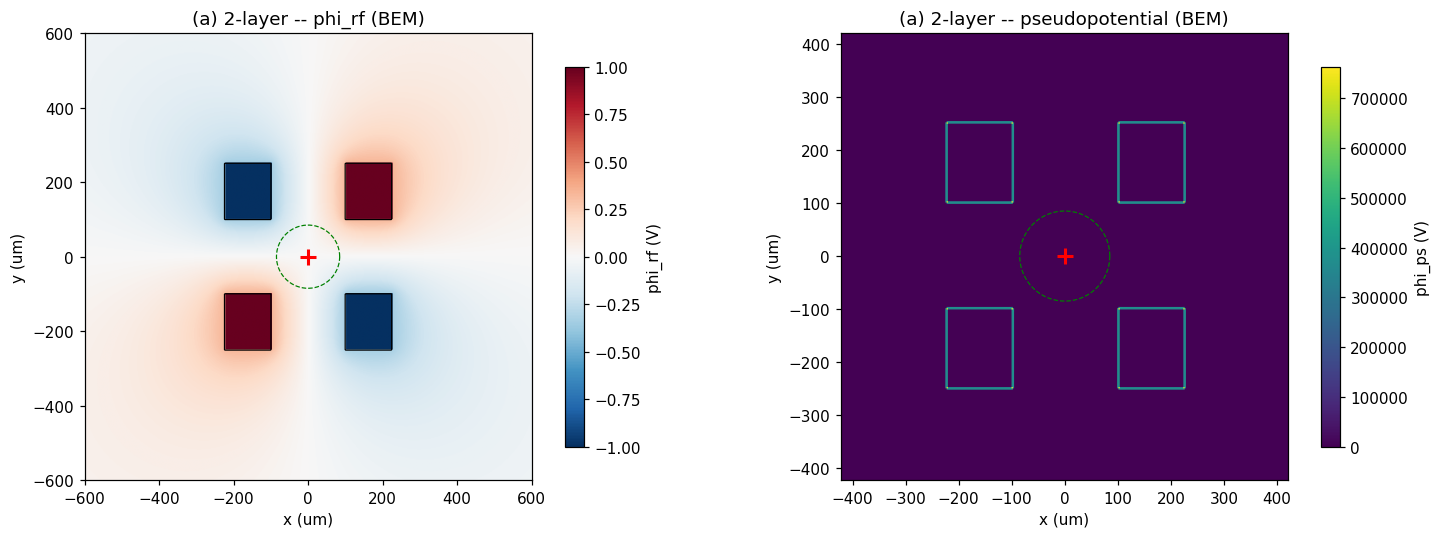

  done (11.8 s)

  (b) Balanced 2-layer
  grid 501x501  domain +/-620 um  dx=2.48 um
  BEM: 50 elements/side
  BEM solved + evaluated in 9.2 s  (736 boundary elements)
    Physics validation (tol=1.0e-03):
      Laplace  nabla^2 V ~ 0 : FAIL  (norm. max = 6.63e-01)
      Electrode voltages      : FAIL  (max rel err = 6.07e-01)
      Far-field decay          : PASS  (Net charge ~ 0; far-field decays.)
  ion at origin (by symmetry)
  R=148.66 um   r_fit=89.20 um
  phi_rf  p2=2.6154e-01
    p3/p2 = 0.0000
    p4/p2 = 0.0423
    p5/p2 = 0.0000
    p6/p2 = 0.1024
    p7/p2 = 0.0000
    p8/p2 = 0.0210
  phi_ps  p2 ~ 0  (radially symmetric -- ratios N/A)


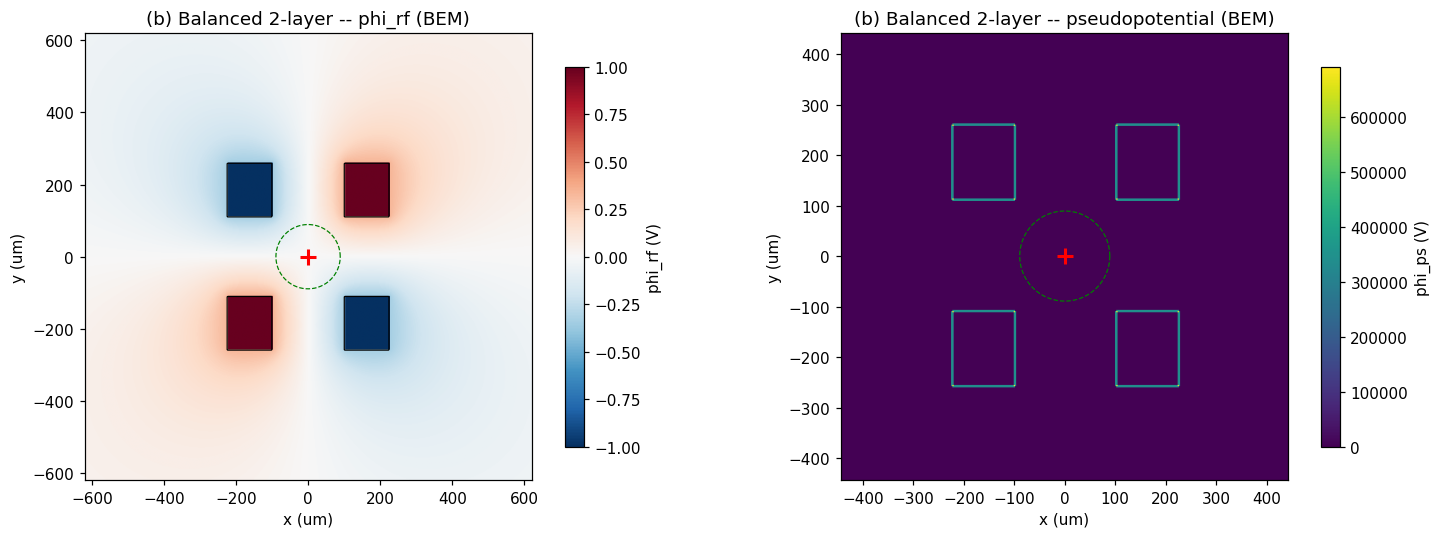

  done (10.7 s)

  (c) 3-layer
  grid 501x501  domain +/-775 um  dx=3.10 um
  BEM: 50 elements/side
  BEM solved + evaluated in 7.6 s  (636 boundary elements)
    Physics validation (tol=1.0e-03):
      Laplace  nabla^2 V ~ 0 : FAIL  (norm. max = 2.04e+00)
      Electrode voltages      : FAIL  (max rel err = 1.40e+03)
      Far-field decay          : PASS  (Net charge != 0; 2-D log divergence expected (not a BEM error).)
  ion at origin (by symmetry)
  R=75.00 um   r_fit=45.00 um
  phi_rf  p2=2.7175e-01
    p3/p2 = 0.0000
    p4/p2 = 0.7291
    p5/p2 = 0.0000
    p6/p2 = 0.1428
    p7/p2 = 0.0000
    p8/p2 = 0.0063
  phi_ps  p2 ~ 0  (radially symmetric -- ratios N/A)


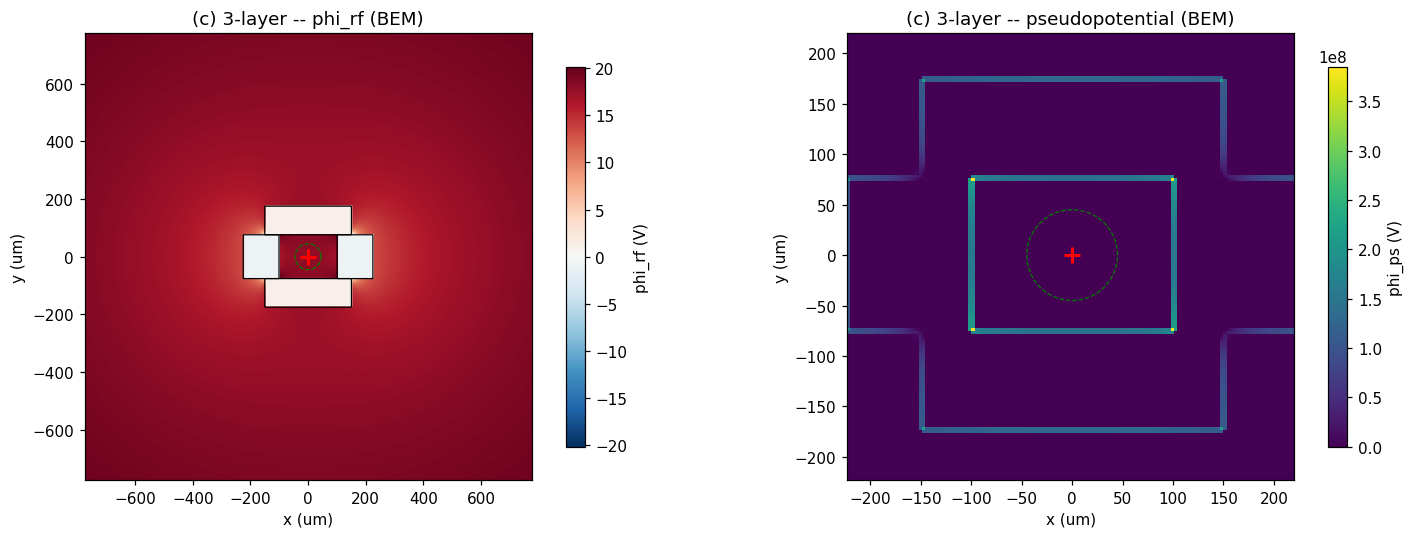

  done (9.3 s)

  (d) 2-layer AlGaAs
  grid 501x501  domain +/-300 um  dx=1.20 um
  BEM: 50 elements/side
  BEM solved + evaluated in 5.4 s  (480 boundary elements)
    Physics validation (tol=1.0e-03):
      Laplace  nabla^2 V ~ 0 : FAIL  (norm. max = 2.20e-01)
      Electrode voltages      : FAIL  (max rel err = 3.71e+00)
      Far-field decay          : PASS  (Net charge != 0; 2-D log divergence expected (not a BEM error).)
  ion at origin (by symmetry)
  R=30.07 um   r_fit=18.04 um
  phi_rf  p2=2.8865e-01
    p3/p2 = 0.0000
    p4/p2 = 0.6248
    p5/p2 = 0.0000
    p6/p2 = 0.4232
    p7/p2 = 0.0000
    p8/p2 = 0.2940
  phi_ps  p2 ~ 0  (radially symmetric -- ratios N/A)


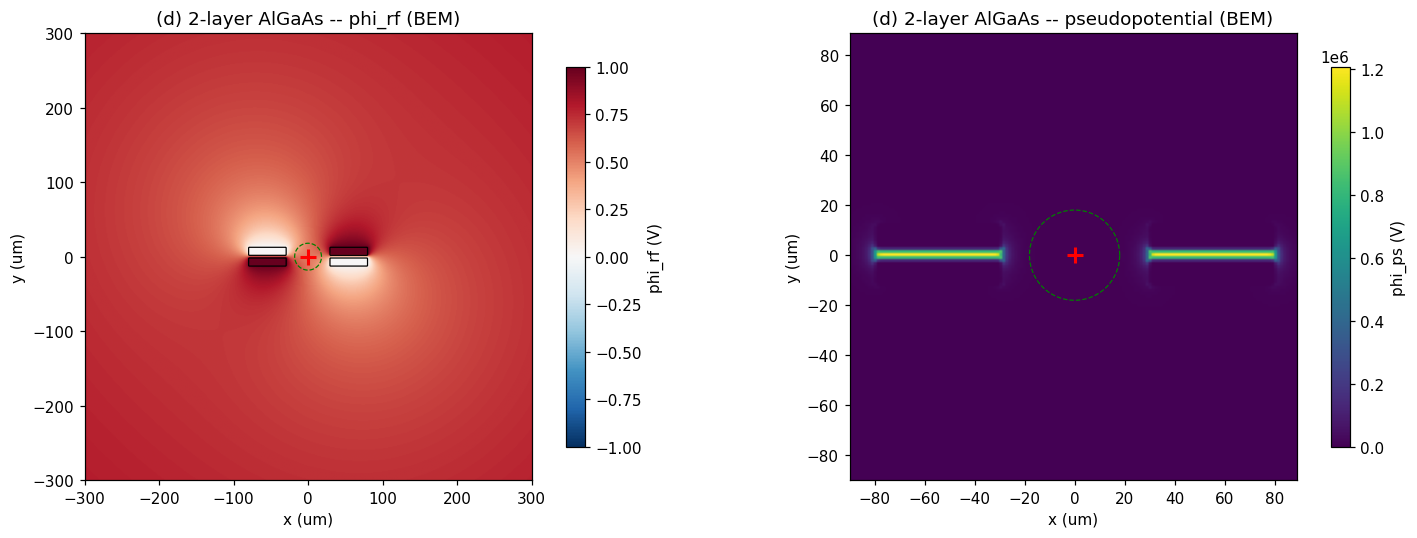

  done (7.1 s)

  (e) In-plane 4-wire
  grid 501x501  domain +/-600 um  dx=2.40 um
  BEM: 50 elements/side
  BEM solved + evaluated in 6.3 s  (508 boundary elements)
    Physics validation (tol=1.0e-03):
      Laplace  nabla^2 V ~ 0 : FAIL  (norm. max = 7.63e-01)
      Electrode voltages      : FAIL  (max rel err = 1.74e+03)
      Far-field decay          : PASS  (Net charge != 0; 2-D log divergence expected (not a BEM error).)
  RF null at (0.00, 0.00)  |grad|=5.843e-07
  R=40.00 um   r_fit=24.00 um
  phi_rf  p2=3.7933e+00
    p3/p2 = 0.0000
    p4/p2 = 0.0705
    p5/p2 = 0.0000
    p6/p2 = 0.0096
    p7/p2 = 0.0000
    p8/p2 = 0.0267
  phi_ps  p2=4.0928e+06
    p3/p2 = 0.0000
    p4/p2 = 1.4879
    p5/p2 = 0.0000
    p6/p2 = 0.0956
    p7/p2 = 0.0000
    p8/p2 = 9.2424


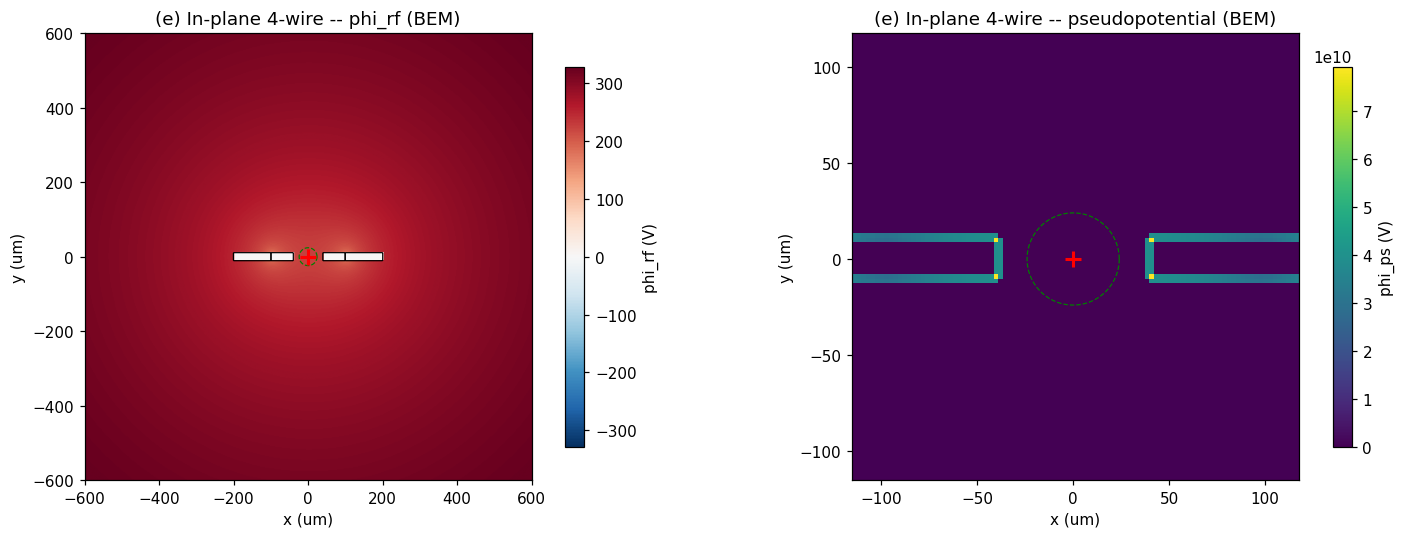

  done (8.2 s)

  (f) 4-wire surface
  grid 501x501  domain +/-438 um  dx=1.75 um
  BEM: 50 elements/side
  BEM solved + evaluated in 6.5 s  (548 boundary elements)
    Physics validation (tol=1.0e-03):
      Laplace  nabla^2 V ~ 0 : FAIL  (norm. max = 7.06e-01)
      Electrode voltages      : FAIL  (max rel err = 3.01e+00)
      Far-field decay          : PASS  (Net charge != 0; 2-D log divergence expected (not a BEM error).)
  RF null at (-41.34, 6.33)  |grad|=-4.362e-02
  R=5.25 um   r_fit=5.25 um
  phi_rf  p2=4.7299e-02
    p3/p2 = 2.9283
    p4/p2 = 0.9100
    p5/p2 = 1.5413
    p6/p2 = 0.9702
    p7/p2 = 0.9863
    p8/p2 = 0.4155
  phi_ps  p2=2.0122e+05
    p3/p2 = 0.3984
    p4/p2 = 0.7386
    p5/p2 = 0.4042
    p6/p2 = 0.2026
    p7/p2 = 0.3829
    p8/p2 = 0.1388


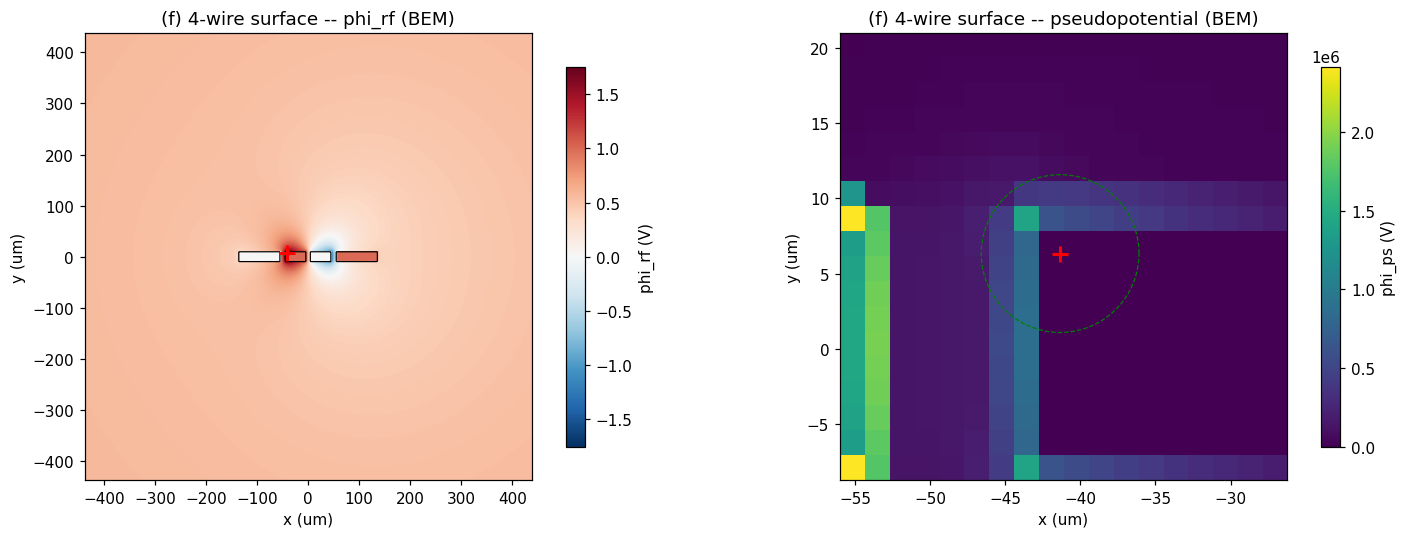

  done (8.4 s)

  (g) 5-wire symm. surface
  grid 501x501  domain +/-500 um  dx=2.00 um
  BEM: 50 elements/side
  BEM solved + evaluated in 8.3 s  (698 boundary elements)
    Physics validation (tol=1.0e-03):
      Laplace  nabla^2 V ~ 0 : FAIL  (norm. max = 7.83e-01)
      Electrode voltages      : FAIL  (max rel err = 5.75e+00)
      Far-field decay          : PASS  (Net charge != 0; 2-D log divergence expected (not a BEM error).)
  RF null at (-32.76, 7.24)  |grad|=-1.912e-01
  R=6.00 um   r_fit=6.00 um
  phi_rf  p2=1.8565e-01
    p3/p2 = 4.6892
    p4/p2 = 0.6268
    p5/p2 = 1.9891
    p6/p2 = 1.2549
    p7/p2 = 1.3314
    p8/p2 = 0.5681
  phi_ps  p2=5.8657e+06
    p3/p2 = 0.2048
    p4/p2 = 0.8597
    p5/p2 = 0.2009
    p6/p2 = 0.2937
    p7/p2 = 0.1349
    p8/p2 = 0.1199


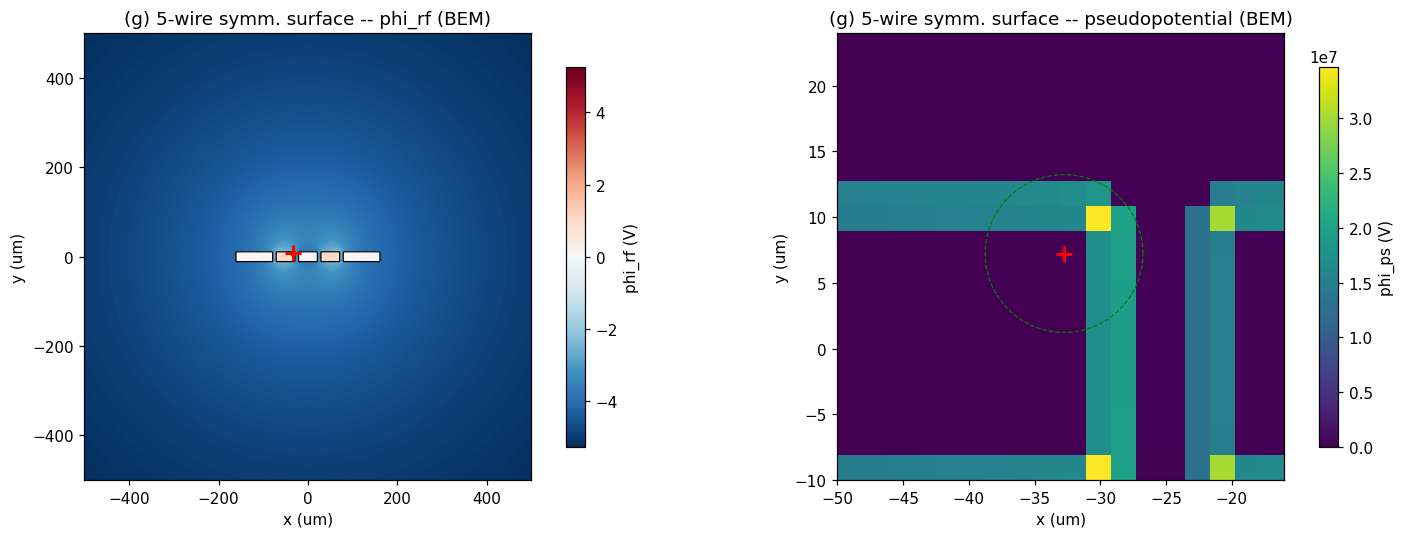

  done (10.2 s)

  (h) 5-wire asymm. surface
  grid 501x501  domain +/-500 um  dx=2.00 um
  BEM: 50 elements/side
  BEM solved + evaluated in 8.6 s  (700 boundary elements)
    Physics validation (tol=1.0e-03):
      Laplace  nabla^2 V ~ 0 : FAIL  (norm. max = 7.97e-01)
      Electrode voltages      : FAIL  (max rel err = 6.05e+00)
      Far-field decay          : PASS  (Net charge != 0; 2-D log divergence expected (not a BEM error).)
  RF null at (-28.76, 7.24)  |grad|=-2.107e-01
  R=6.00 um   r_fit=6.00 um
  phi_rf  p2=2.1082e-01
    p3/p2 = 4.5555
    p4/p2 = 0.6238
    p5/p2 = 1.9381
    p6/p2 = 1.2249
    p7/p2 = 1.2959
    p8/p2 = 0.5556
  phi_ps  p2=7.1478e+06
    p3/p2 = 0.2066
    p4/p2 = 0.8503
    p5/p2 = 0.2054
    p6/p2 = 0.2874
    p7/p2 = 0.1413
    p8/p2 = 0.1195


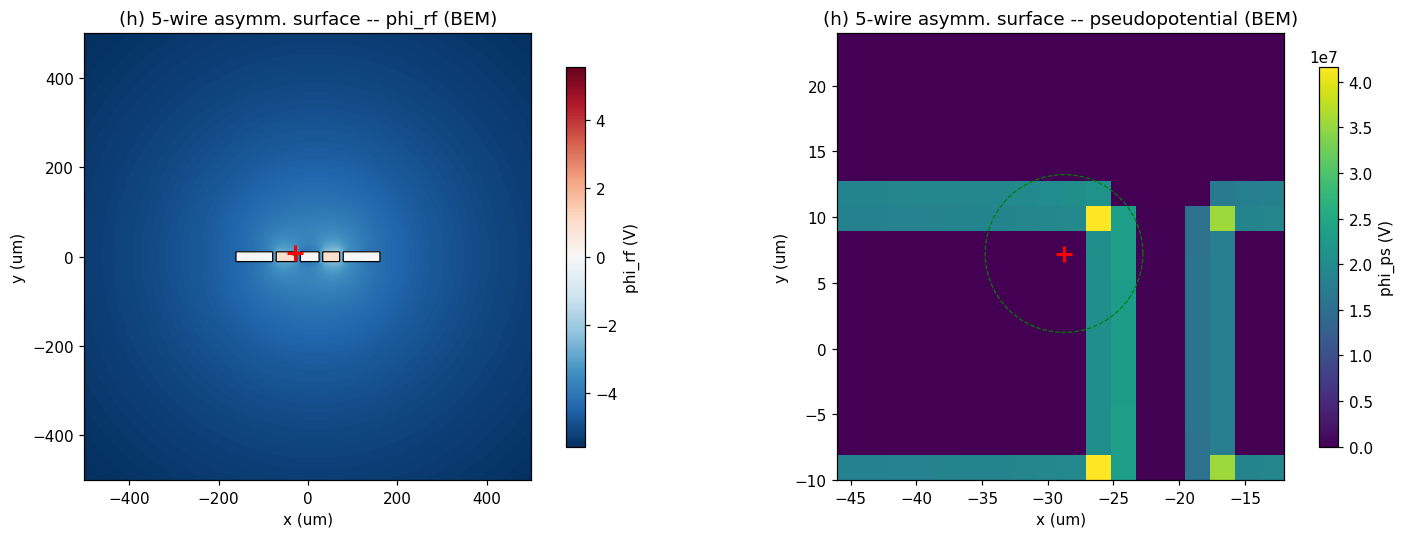

  done (10.7 s)

All BEM simulations complete.


In [16]:
# ============================================================
# Cell 7 -- Run all 8 traps
# ============================================================

CONFIGS = [
    (trap_a_2layer,       '(a) 2-layer',              2.0),
    (trap_b_balanced,     '(b) Balanced 2-layer',     2.0),
    (trap_c_3layer,       '(c) 3-layer',              3.0),
    (trap_d_algaas,       '(d) 2-layer AlGaAs',       2.5),
    (trap_e_inplane4,     '(e) In-plane 4-wire',      2.5),
    (trap_f_4wire_surface,'(f) 4-wire surface',       2.5),
    (trap_g_5wire_symm,   '(g) 5-wire symm. surface', 2.5),
    (trap_h_5wire_asymm,  '(h) 5-wire asymm. surface',2.5),
]

GRID = 501
N_PER_SIDE = 50
PHYSICS_TOL = 1e-3

all_results = {}
for builder, name, scale in CONFIGS:
    try:
        all_results[name] = simulate_trap_bem(
            builder, name,
            grid=GRID, dom_scale=scale,
            n_per_side=N_PER_SIDE,
            physics_tol=PHYSICS_TOL,
            plot=True)
    except Exception as exc:
        import traceback; traceback.print_exc()
        nan = {f'p{n}/p2': np.nan for n in range(3, 9)}
        all_results[name] = {'rf_ratios': nan, 'ps_ratios': nan,
                             'validation': None}

print('\n' + '='*60 + '\nAll BEM simulations complete.\n' + '='*60)

In [17]:
# ============================================================
# Cell 8 -- Comparison tables + physics validation summary
# ============================================================

cols = [f'p{n}/p2' for n in range(3, 9)]

rf_df = pd.DataFrame({n: r['rf_ratios'] for n, r in all_results.items()}).T.reindex(columns=cols)
ps_df = pd.DataFrame({n: r['ps_ratios'] for n, r in all_results.items()}).T.reindex(columns=cols)

ref = {
    '(a) 2-layer':              {'p3/p2':0.0015,'p4/p2':0.0284,'p5/p2':0.0005,'p6/p2':0.1171,'p7/p2':0.0036,'p8/p2':0.0039},
    '(b) Balanced 2-layer':     {'p3/p2':0.0011,'p4/p2':0.0158,'p5/p2':0.0009,'p6/p2':0.1156,'p7/p2':0.0005,'p8/p2':0.0242},
    '(c) 3-layer':              {'p3/p2':0.0006,'p4/p2':0.1904,'p5/p2':0.0006,'p6/p2':0.0554,'p7/p2':0.0005,'p8/p2':0.0203},
    '(d) 2-layer AlGaAs':       {'p3/p2':0.0026,'p4/p2':0.6005,'p5/p2':0.0054,'p6/p2':0.4340,'p7/p2':0.0143,'p8/p2':0.2642},
    '(e) In-plane 4-wire':      {'p3/p2':0.0008,'p4/p2':0.3443,'p5/p2':0.0009,'p6/p2':0.1191,'p7/p2':0.0010,'p8/p2':0.0330},
    '(f) 4-wire surface':       {'p3/p2':0.9731,'p4/p2':0.6931,'p5/p2':0.4255,'p6/p2':0.2442,'p7/p2':0.1481,'p8/p2':0.1074},
    '(g) 5-wire symm. surface': {'p3/p2':0.9963,'p4/p2':0.6202,'p5/p2':0.2640,'p6/p2':0.0408,'p7/p2':0.1504,'p8/p2':0.1426},
    '(h) 5-wire asymm. surface':{'p3/p2':1.0100,'p4/p2':0.6401,'p5/p2':0.2737,'p6/p2':0.0569,'p7/p2':0.1195,'p8/p2':0.1455},
}
ref_df = pd.DataFrame(ref).T.reindex(columns=cols)

fmt = lambda x: f'{x:.4f}'

print('\n' + '='*80)
print('  BEM SIMULATED  phi_rf  MULTIPOLE RATIOS')
print('='*80)
print(rf_df.to_string(float_format=fmt))

print('\n' + '='*80)
print('  REFERENCE  (Table 3.2)')
print('='*80)
print(ref_df.to_string(float_format=fmt))

print('\n' + '='*80)
print('  |sim_rf - ref|  ABSOLUTE DIFFERENCE')
print('='*80)
print((rf_df - ref_df).abs().to_string(float_format=fmt))

print('\n' + '='*80)
print('  BEM SIMULATED  phi_ps  (PSEUDOPOTENTIAL)  MULTIPOLE RATIOS')
print('  Note: For symmetric traps (a)-(e) the pseudopotential is nearly')
print('  radially symmetric at the origin, so p2 ~ 0 and ratios are N/A.')
print('  Pseudopotential multipoles are most meaningful for surface traps.')
print('='*80)
print(ps_df.to_string(float_format=fmt))

# ---- Physics validation summary table ----
print('\n' + '='*80)
print(f'  PHYSICS VALIDATION SUMMARY  (tolerance = {PHYSICS_TOL:.1e})')
print('='*80)
header = f'{"Trap":<30s}  {"Laplace":>8s}  {"Electrode V":>12s}  {"Far-field":>10s}  {"Overall":>8s}'
print(header)
print('-' * len(header))
for name, r in all_results.items():
    v = r.get('validation')
    if v is None:
        print(f'{name:<30s}  {"N/A":>8s}  {"N/A":>12s}  {"N/A":>10s}  {"N/A":>8s}')
    else:
        tag = lambda ok: 'PASS' if ok else 'FAIL'
        print(f'{name:<30s}  '
              f'{tag(v["laplace"]["passed"]):>8s}  '
              f'{tag(v["electrode_voltage"]["passed"]):>12s}  '
              f'{tag(v["far_field"]["passed"]):>10s}  '
              f'{tag(v["all_passed"]):>8s}')

rf_df.to_csv('bem_rf_ratios.csv')
ps_df.to_csv('bem_ps_ratios.csv')
ref_df.to_csv('ref_ratios.csv')
print('\nCSVs saved: bem_rf_ratios.csv, bem_ps_ratios.csv, ref_ratios.csv')


  BEM SIMULATED  phi_rf  MULTIPOLE RATIOS
                           p3/p2  p4/p2  p5/p2  p6/p2  p7/p2  p8/p2
(a) 2-layer               0.0000 0.0011 0.0000 0.1046 0.0000 0.0006
(b) Balanced 2-layer      0.0000 0.0423 0.0000 0.1024 0.0000 0.0210
(c) 3-layer               0.0000 0.7291 0.0000 0.1428 0.0000 0.0063
(d) 2-layer AlGaAs        0.0000 0.6248 0.0000 0.4232 0.0000 0.2940
(e) In-plane 4-wire       0.0000 0.0705 0.0000 0.0096 0.0000 0.0267
(f) 4-wire surface        2.9283 0.9100 1.5413 0.9702 0.9863 0.4155
(g) 5-wire symm. surface  4.6892 0.6268 1.9891 1.2549 1.3314 0.5681
(h) 5-wire asymm. surface 4.5555 0.6238 1.9381 1.2249 1.2959 0.5556

  REFERENCE  (Table 3.2)
                           p3/p2  p4/p2  p5/p2  p6/p2  p7/p2  p8/p2
(a) 2-layer               0.0015 0.0284 0.0005 0.1171 0.0036 0.0039
(b) Balanced 2-layer      0.0011 0.0158 0.0009 0.1156 0.0005 0.0242
(c) 3-layer               0.0006 0.1904 0.0006 0.0554 0.0005 0.0203
(d) 2-layer AlGaAs        0.0026 0.6005 0.0054 

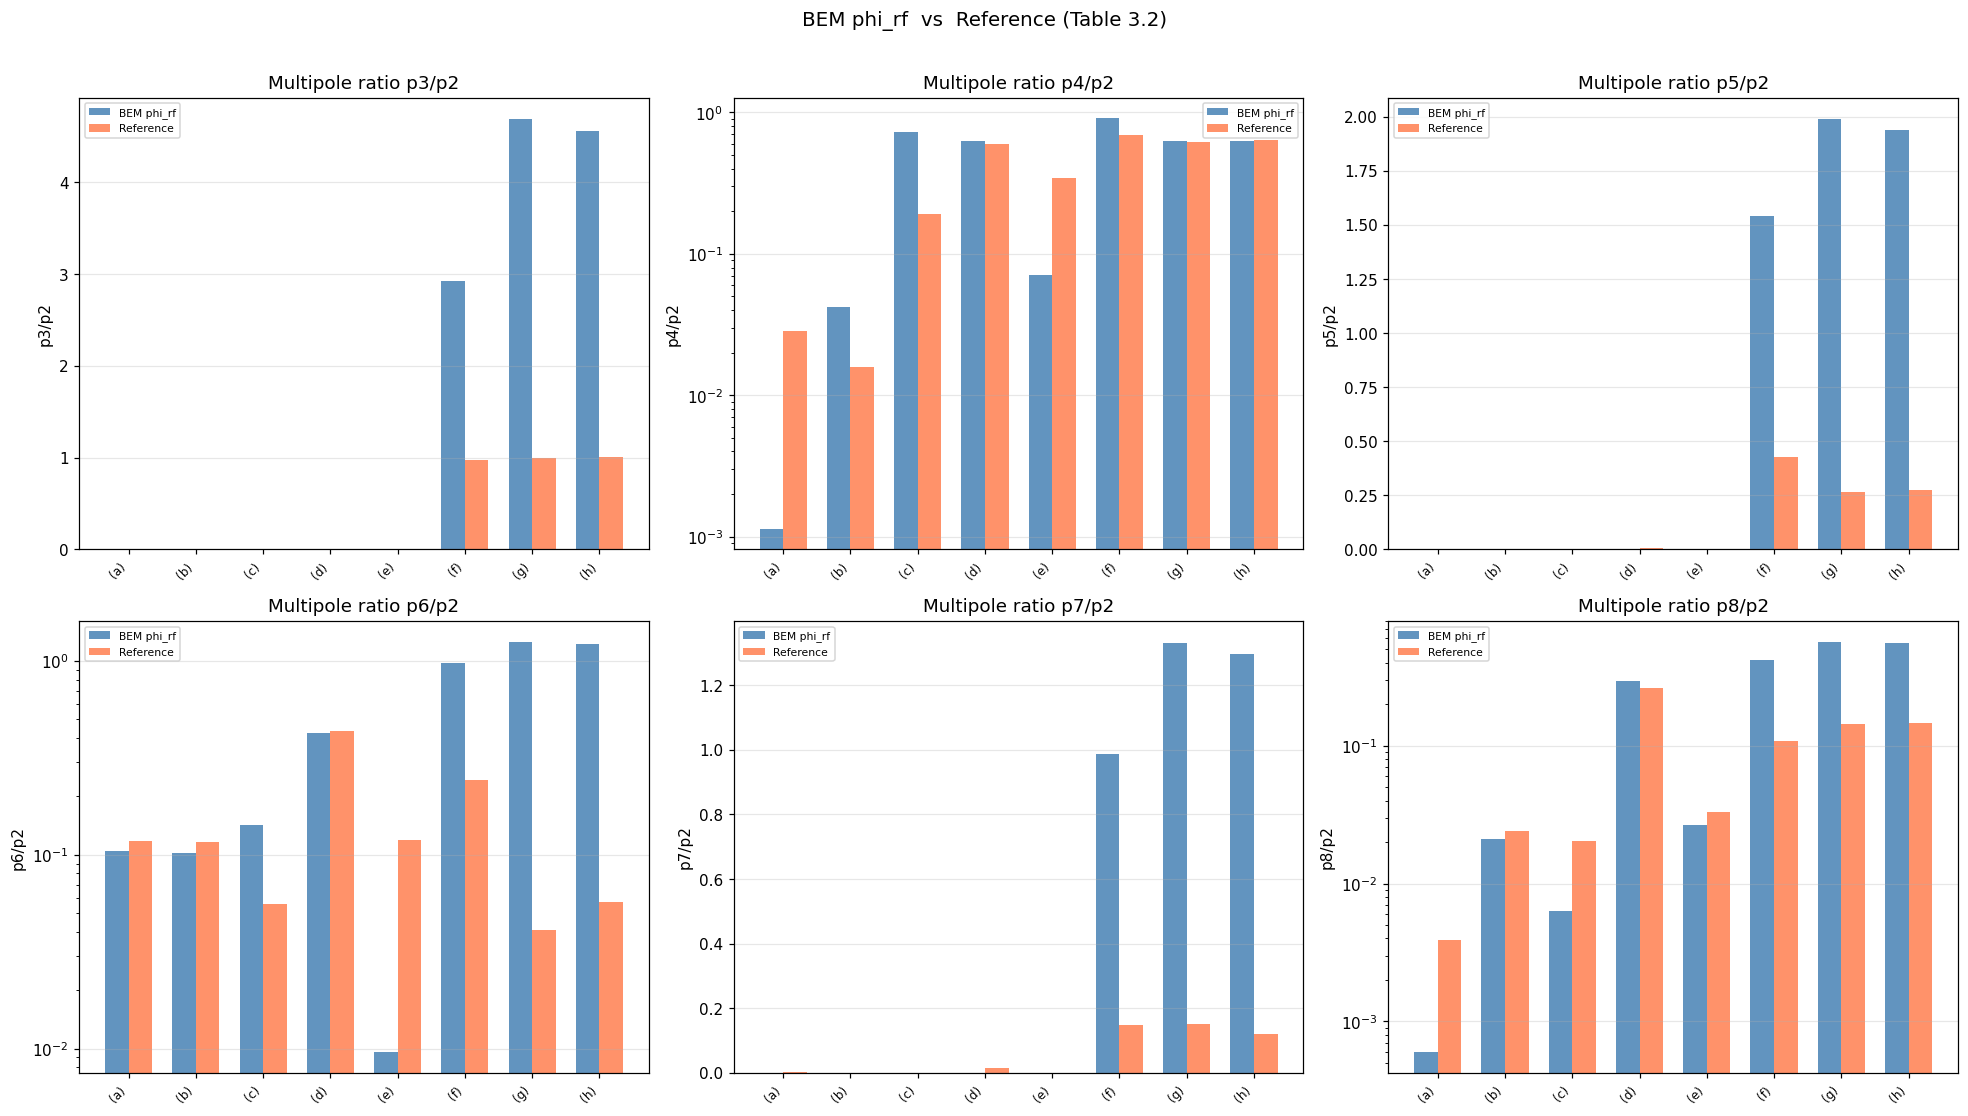

Saved bem_multipole_comparison.png


In [18]:
# ============================================================
# Cell 9 -- Bar-chart comparison
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, n in enumerate(range(3, 9)):
    ax  = axes.flat[idx]
    col = f'p{n}/p2'
    x   = np.arange(len(rf_df))
    w   = 0.35

    ax.bar(x - w/2, rf_df[col].values, w, label='BEM phi_rf', alpha=0.85, color='steelblue')
    ax.bar(x + w/2, ref_df[col].values, w, label='Reference',  alpha=0.85, color='coral')

    ax.set_ylabel(col)
    ax.set_title(f'Multipole ratio {col}')
    ax.set_xticks(x)
    ax.set_xticklabels([s.split(')')[0]+')' for s in rf_df.index],
                       rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)
    if n in (4, 6, 8):
        ax.set_yscale('log')

plt.suptitle('BEM phi_rf  vs  Reference (Table 3.2)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('bem_multipole_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved bem_multipole_comparison.png')